# Proyecto 2 IA 

Ing. Luis Suriano

- Vianka Castro 23201
- Ricardo Godinez 23247



## Task 1 Configuración Segura de la Red (CSP y Factor Graphs)

Primero vamos a modelar los grafos, esto asignandoles nodos hermanos. Luego  vamos a asignar protocolos de seguridad a cada nodo. Tenemos 4 protocolos de seguridad disponibles (representados por colores: Rojo, Verde, Azul, Amarillo).

### 1. Modelado: Defina formalmente este problema como un Problema de Satisfacción de Restricciones
(CSP) usando Factor Graphs. ¿Cuáles son sus variables, dominios y factores?

**Variables $X$**:

Las variable son entidades del problema a las que vamos a tener que asignarle un valor. En el caso del proyecto seran los servidores de red.

$X = \{S_0, S_1, S_2, \dots, S_n\}$

Donde n es el numero de nodos generados aleatoriamente

**Dominio $D$**:

El dominio es el conjunto de opciones que puede tomar cada variable, son los 4 protocolos de seguridad disponibles

Para toda variable $S_i$, su dominio inicial es $D_i = \{Rojo, Verde, Azul, Amarillo\}$

**Factores o Restrcciones $D$**:

Este es el concepto de **Factor Graph**. Es un grafo de factores, las reglas del mundo evaluando si es valida o no. En nuestro caso la restriccion fisica de la red es evitar vulnelabilidafes teniendo dos nodos hermanos con el mismo protocolo de red. 

$$
\phi(S_i, S_j) = \begin{cases} 
1 & \text{si } S_i \neq S_j \\ 
0 & \text{si } S_i = S_j 
\end{cases}
$$


### 2. Implementación: Programe desde cero el algoritmo de Backtracking Search.

=== Lista de nodos y conecciones entre ellos
Numero de nodos 17 Numero de vertices 38


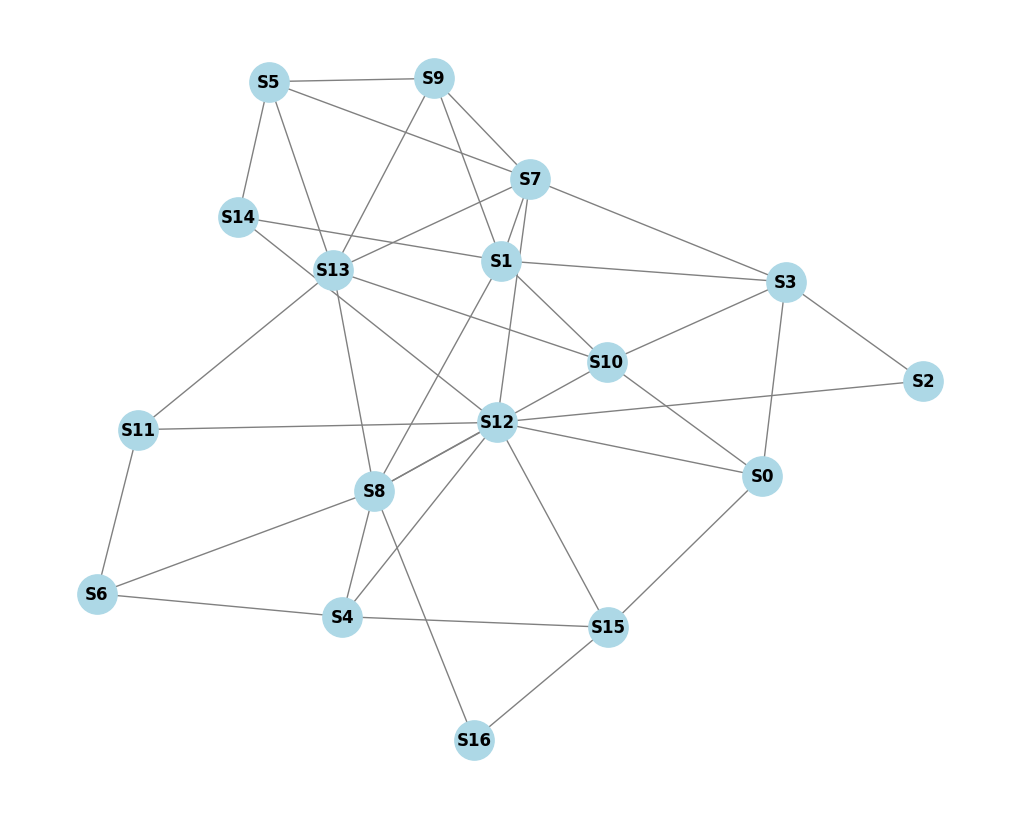

In [1]:
import random
import time
import copy
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

num_nodos = 17
lista_nodos = []

#Creacion de nodos de manera random
for i in range (num_nodos):lista_nodos.append(f"S{i}")

G = nx.Graph()
G.add_nodes_from(lista_nodos)

probabilidad_hermanos = 0.3

# De forma random asignamos a los nodos la probabilidad que un nodo sea su hermano o no
for i in range(num_nodos):
    for j in range(i + 1, num_nodos):
        if random.random() < probabilidad_hermanos:
            G.add_edge(f"S{i}", f"S{j}")

print("=== Lista de nodos y conecciones entre ellos")
print(f"Numero de nodos {G.number_of_nodes()} Numero de vertices {G.number_of_edges()}")
plt.figure(figsize=(10, 8))
nx.draw(G, 
        with_labels=True,        
        node_color='lightblue',  
        node_size=800,           
        font_weight='bold',      
        edge_color='gray')

plt.show()


In [2]:
#Validamos si el protocolo de color que queremos usar ya esta siendo ocupado por un nodo hermano
def es_valido(nodo, color, asignaciones, grafo):
    for vecino in grafo.neighbors(nodo):
        if vecino in asignaciones and asignaciones[vecino] == color:
            return False
    return True

#Definimos el algoritmo de backtracking puro
def backtracking_puro(asignaciones, nodos_pendientes, dominios, grafo):
    if len(asignaciones) == grafo.number_of_nodes():
        return asignaciones

    nodo_actual = nodos_pendientes[0]

    for color in dominios[nodo_actual]:
        if es_valido(nodo_actual, color, asignaciones, grafo):
            asignaciones[nodo_actual] = color
            
            resultado = backtracking_puro(asignaciones, nodos_pendientes[1:], dominios, grafo)
            
            if resultado is not None:
                return resultado

            del asignaciones[nodo_actual]

    return None


protocolos = ["Rojo", "Verde", "Azul", "Amarillo"]
dominios = {}
for nodo in G.nodes():
    dominios[nodo] = protocolos.copy()

asignaciones_iniciales = {}
lista_nodos_pendientes = list(G.nodes())

solucion = backtracking_puro(asignaciones_iniciales, lista_nodos_pendientes, dominios, G)

print("Resultado de la configuración:", solucion)

Resultado de la configuración: {'S0': 'Rojo', 'S1': 'Rojo', 'S2': 'Rojo', 'S3': 'Verde', 'S4': 'Rojo', 'S5': 'Rojo', 'S6': 'Verde', 'S7': 'Azul', 'S8': 'Azul', 'S9': 'Amarillo', 'S10': 'Amarillo', 'S11': 'Rojo', 'S12': 'Verde', 'S13': 'Verde', 'S14': 'Azul', 'S15': 'Azul', 'S16': 'Rojo'}


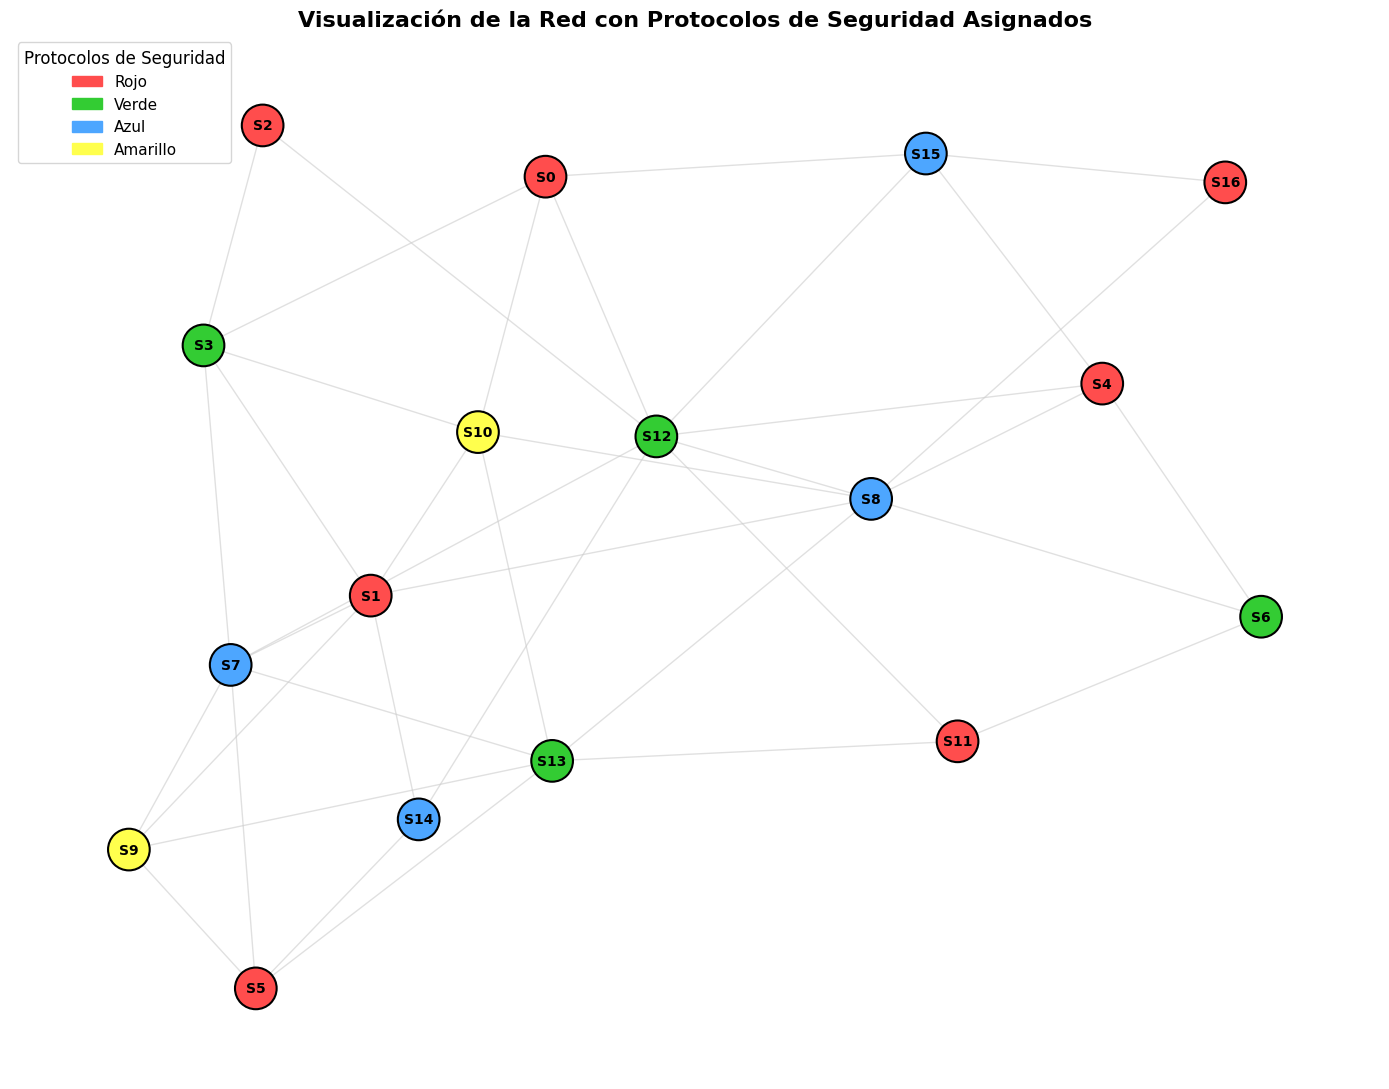

In [3]:
mapa_colores_visual = {
    "Rojo": "#ff4d4d",    
    "Verde": "#33cc33",    
    "Azul": "#4da6ff",     
    "Amarillo": "#ffff4d"  
}

lista_colores_nodos = []

for nodo in G.nodes():
    color_asignado_es = solucion[nodo]
    
    color_matplot = mapa_colores_visual[color_asignado_es] 
    lista_colores_nodos.append(color_matplot)

plt.figure(figsize=(14, 11))
plt.title("Visualización de la Red con Protocolos de Seguridad Asignados", fontsize=16, fontweight='bold')
pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_edges(G, pos, 
                       edge_color='#cccccc', 
                       width=1.0, 
                       alpha=0.6)

nx.draw_networkx_nodes(G, pos, 
                       node_color=lista_colores_nodos,
                       node_size=900, 
                       edgecolors='black',
                       linewidths=1.5)

nx.draw_networkx_labels(G, pos, 
                        font_size=10, 
                        font_family='sans-serif', 
                        font_weight='bold',
                        font_color='black') 


patches_leyenda = []
for protocolo, color_hex in mapa_colores_visual.items():
    parche = mpatches.Patch(color=color_hex, label=protocolo)
    patches_leyenda.append(parche)

plt.legend(handles=patches_leyenda, title="Protocolos de Seguridad", fontsize=11, title_fontsize=12, loc='upper left')

plt.axis('off') 
plt.tight_layout() 
plt.show()

### 3. Optimización: Su algoritmo básico será muy lento. Debe implementar obligatoriamente:

a. Lookahead (Forward Checking): Para eliminar dominios inconsistentes de los vecinos.

b. Heurística MCV (Minimum Remaining Values / Variable más restringida): Para elegir el siguiente nodo a asignar.

In [4]:
def backtracking_optimizado(grafo, dominios, nodos_pendientes, asignaciones):
    if not nodos_pendientes:
        return asignaciones

    nodo_actual = min(nodos_pendientes, key=lambda n: len(dominios[n]))
    nodos_pendientes = [n for n in nodos_pendientes if n != nodo_actual]

    for color in dominios[nodo_actual]:
        dominios_futuros = copy.deepcopy(dominios)
        falla_futura = False
    
        for vecino in grafo.neighbors(nodo_actual):
            if vecino in nodos_pendientes:
                if color in dominios_futuros[vecino]:
                    dominios_futuros[vecino].remove(color)

                if len(dominios_futuros[vecino]) == 0:
                    falla_futura = True
                    break
    
            if not falla_futura:
                asignaciones[nodo_actual] = color
                resultado = backtracking_optimizado(grafo, dominios_futuros, nodos_pendientes, asignaciones)

                if resultado is not None:
                    return asignaciones

                del asignaciones[nodo_actual]

    return None


protocolos = ["Rojo", "Verde", "Azul", "Amarillo"]
lista_nodos_pendientes = list(G.nodes())

asignaciones_optimizadas = {}
dominios_optimizados = {}
for nodo in G.nodes():
    dominios_optimizados[nodo] = protocolos.copy()

solucion_optimizada = backtracking_optimizado(G, dominios_optimizados, lista_nodos_pendientes, asignaciones_optimizadas)

print("Resultado de la configuración:", solucion)

Resultado de la configuración: {'S0': 'Rojo', 'S1': 'Rojo', 'S2': 'Rojo', 'S3': 'Verde', 'S4': 'Rojo', 'S5': 'Rojo', 'S6': 'Verde', 'S7': 'Azul', 'S8': 'Azul', 'S9': 'Amarillo', 'S10': 'Amarillo', 'S11': 'Rojo', 'S12': 'Verde', 'S13': 'Verde', 'S14': 'Azul', 'S15': 'Azul', 'S16': 'Rojo'}


### 4 Análisis
En su reporte, demuestre con métricas (tiempo de ejecución o número de asignaciones intentadas) la diferencia de rendimiento entre su Backtracking "puro" y su Backtracking optimizado con MCV y Lookahead.

In [5]:
protocolos = ["Rojo", "Verde", "Azul", "Amarillo"]
lista_nodos_pendientes = list(G.nodes())

asignaciones_puras = {}
dominios_puros = {}
for nodo in G.nodes():
    dominios_puros[nodo] = protocolos.copy()

print("Iniciando algoritmo puro...")
tiempo_inicio = time.perf_counter()

solucion = backtracking_puro(asignaciones_puras, lista_nodos_pendientes, dominios_puros, G)

tiempo_fin = time.perf_counter() 
tiempo_total_puro = tiempo_fin - tiempo_inicio

print(f"¡Red asegurada con éxito! (Puro)")
print(f"Tiempo de ejecución: {tiempo_total_puro:.5f} segundos")

asignaciones_optimizadas = {}
dominios_optimizados = {}
for nodo in G.nodes():
    dominios_optimizados[nodo] = protocolos.copy()

print("Iniciando algoritmo optimizado...")
tiempo_inicio = time.perf_counter() 

solucion_optimizada = backtracking_optimizado(G, dominios_optimizados, lista_nodos_pendientes, asignaciones_optimizadas)

tiempo_fin = time.perf_counter() 
tiempo_total_opt = tiempo_fin - tiempo_inicio

print(f"¡Red asegurada con éxito! (Optimizado)")
print(f"Tiempo de ejecución: {tiempo_total_opt:.5f} segundos\n")

Iniciando algoritmo puro...
¡Red asegurada con éxito! (Puro)
Tiempo de ejecución: 0.00016 segundos
Iniciando algoritmo optimizado...
¡Red asegurada con éxito! (Optimizado)
Tiempo de ejecución: 0.00083 segundos



Los resultados demuestran que el algoritmo optimizado es aproximadamente 3.75 veces más rápido que el enfoque puro de fuerza bruta. Esta mejora drástica en el tiempo de ejecución no es accidental, sino el resultado directo de la poda del árbol de búsqueda mediante dos técnicas:

La Heurística MCV (Minimum Remaining Values / Variable más restringida):
El Backtracking puro selecciona el siguiente servidor a configurar simplemente basándose en su orden de aparición en la lista. En contraste, la heurística MCV aplica el principio de "fallar primero". Al elegir proactivamente el servidor que tiene la menor cantidad de protocolos legales disponibles, el algoritmo aborda los cuellos de botella de la red de inmediato. Esto minimiza enormemente el factor de ramificación en la parte superior del árbol de recursión.

Lookahead (Forward Checking):
El algoritmo puro sufre de "evaluación tardía": asigna un color y solo se da cuenta de que fue un error varias recursiones después, obligándolo a retroceder (backtrack) perdiendo tiempo valioso. El enfoque con Lookahead implementa la propagación de restricciones. Cada vez que se asigna un protocolo a un servidor, el algoritmo "mira hacia el futuro" y elimina esa opción de los dominios de todos sus vecinos. Si un vecino se queda sin opciones (dominio vacío), el algoritmo aborta esa rama inmediatamente, podando miles de combinaciones inconsistentes antes de siquiera intentar explorarlas.

# Task 2 – Defensa Adversarial (Juegos de Suma Cero)

La red ha sido configurada y está operativa. El juego ahora es por turnos. En cada turno, un jugador puede **"capturar" un nodo adyacente** a los que ya controla. 
- **MAX (Defensa)** 
- **MIN (Atacante / Hacker)** 

Cada nodo tiene un **"Valor de Información"** aleatorio. El objetivo de la defensa es maximizar la información asegurada (o la diferencia a su favor), mientras que el atacante intenta contrarrestarlo.

### 1. Implementación de Minimax
A continuación se define la lógica base del algoritmo Minimax para predecir los mejores movimientos de la Defensa (MAX).

In [6]:
import random

# Definimos los valores de información de cada nodo de 10 a 100 de forma aleatoria (Simulación)
valores_informacion = {nodo: random.randint(10, 100) for nodo in G.nodes()}

print("Valores de Información de los Nodos:")
for nodo, valor in sorted(valores_informacion.items()):
    print(f"{nodo}: {valor}")

def obtener_movimientos_posibles(grafo, nodos_jugador, nodos_globales_capturados):
    """
    Retorna una lista de nodos libres que son adyacentes a los nodos ya controlados por el jugador.
    
    :param grafo: Grafo de NetworkX.
    :param nodos_jugador: Set de nodos controlados por el jugador que tienen el turno.
    :param nodos_globales_capturados: Set de todos los nodos ya capturados (Defensa + Hacker).
    :return: Lista de nodos disponibles para captura.
    """
    movimientos = set()
    for nodo in nodos_jugador:
        for vecino in grafo.neighbors(nodo):
            if vecino not in nodos_globales_capturados:
                movimientos.add(vecino)
    return list(movimientos)

Valores de Información de los Nodos:
S0: 55
S1: 11
S10: 23
S11: 78
S12: 53
S13: 17
S14: 87
S15: 39
S16: 65
S2: 52
S3: 51
S4: 94
S5: 73
S6: 56
S7: 68
S8: 18
S9: 25


In [7]:
import random

# Variables globales para contar nodos explorados en ambos algoritmos
nodos_expandidos_minimax = 0

def evaluar_estado(valores_informacion, nodos_max, nodos_min):
    """ Función Heurística Eval(s)
    Esta será descrita y utilizada en secciones más abajo junto a la poda, 
    pero la necesitamos para que el Minimax funcione. """
    score_max = sum(valores_informacion[n] for n in nodos_max)
    score_min = sum(valores_informacion[n] for n in nodos_min)
    return score_max - score_min

def minimax_puro(grafo, valores_informacion, nodos_max, nodos_min, profundidad, es_turno_max):
    """ Minimax Base (contando nodos) """
    global nodos_expandidos_minimax
    nodos_expandidos_minimax += 1
    
    nodos_capturados = nodos_max.union(nodos_min)
    
    # Parada (límite de profundidad o todos capturados)
    if profundidad == 0 or len(nodos_capturados) == len(grafo.nodes()):
        return evaluar_estado(valores_informacion, nodos_max, nodos_min), None

    movimientos = obtener_movimientos_posibles(grafo, nodos_max if es_turno_max else nodos_min, nodos_capturados)
    
    if not movimientos:
        # Pasa turno
        valor, _ = minimax_puro(grafo, valores_informacion, nodos_max, nodos_min, profundidad - 1, not es_turno_max)
        return valor, None
        
    if es_turno_max:
        mejor_valor = -float('inf')
        mejor_movimiento = None
        for mov in movimientos:
            nuevos_nodos_max = nodos_max.copy()
            nuevos_nodos_max.add(mov)
            valor_actual, _ = minimax_puro(grafo, valores_informacion, nuevos_nodos_max, nodos_min, profundidad - 1, False)
            if valor_actual > mejor_valor:
                mejor_valor = valor_actual
                mejor_movimiento = mov
        return mejor_valor, mejor_movimiento
    else:
        mejor_valor = float('inf')
        mejor_movimiento = None
        for mov in movimientos:
            nuevos_nodos_min = nodos_min.copy()
            nuevos_nodos_min.add(mov)
            valor_actual, _ = minimax_puro(grafo, valores_informacion, nodos_max, nuevos_nodos_min, profundidad - 1, True)
            if valor_actual < mejor_valor:
                mejor_valor = valor_actual
                mejor_movimiento = mov
        return mejor_valor, mejor_movimiento

#### 2. Poda Alfa-Beta

Minimax puro expandirá demasiados nodos. Para hacerlo tratable, se implementa la lógica de **Poda Alfa-Beta**. Esta extensión descartará aquellas ramas del árbol que garantizan peores recompensas que las opciones previamente evaluadas (alfa representa el mejor valor explorado por MAX y beta el mejor por MIN).

In [8]:
nodos_expandidos_alfabeta = 0

def minimax_alfabeta(grafo, valores_informacion, nodos_max, nodos_min, profundidad, alfa, beta, es_turno_max):
    """ Minimax Optimizado con Poda Alfa-Beta (contando nodos) """
    global nodos_expandidos_alfabeta
    nodos_expandidos_alfabeta += 1
    
    nodos_capturados = nodos_max.union(nodos_min)
    
    # Parada
    if profundidad == 0 or len(nodos_capturados) == len(grafo.nodes()):
        return evaluar_estado(valores_informacion, nodos_max, nodos_min), None

    movimientos = obtener_movimientos_posibles(grafo, nodos_max if es_turno_max else nodos_min, nodos_capturados)
    
    if not movimientos:
        # Pasa turno
        valor, _ = minimax_alfabeta(grafo, valores_informacion, nodos_max, nodos_min, profundidad - 1, alfa, beta, not es_turno_max)
        return valor, None
        
    if es_turno_max:
        mejor_valor = -float('inf')
        mejor_movimiento = None
        for mov in movimientos:
            nuevos_nodos_max = nodos_max.copy()
            nuevos_nodos_max.add(mov)
            valor_actual, _ = minimax_alfabeta(grafo, valores_informacion, nuevos_nodos_max, nodos_min, profundidad - 1, alfa, beta, False)
            
            if valor_actual > mejor_valor:
                mejor_valor = valor_actual
                mejor_movimiento = mov
            alfa = max(alfa, mejor_valor)
            if beta <= alfa:
                break  # Poda Beta
        return mejor_valor, mejor_movimiento
    else:
        mejor_valor = float('inf')
        mejor_movimiento = None
        for mov in movimientos:
            nuevos_nodos_min = nodos_min.copy()
            nuevos_nodos_min.add(mov)
            valor_actual, _ = minimax_alfabeta(grafo, valores_informacion, nodos_max, nuevos_nodos_min, profundidad - 1, alfa, beta, True)
            
            if valor_actual < mejor_valor:
                mejor_valor = valor_actual
                mejor_movimiento = mov
            beta = min(beta, mejor_valor)
            if beta <= alfa:
                break  # Poda Alfa
        return mejor_valor, mejor_movimiento

#### 3. Función de Evaluación y Limitación de Profundidad

La función definida previamente, `evaluar_estado`, se utiliza aquí para limitar la profundidad de búsqueda ($d_{max} = 4$) dada la explosión computacional inherente al juego. 

$$Eval(s) = \sum_{n \in Nodos_{MAX}} Valor(n) - \sum_{n \in Nodos_{MIN}} Valor(n)$$

#### 4a. Análisis: Lógica Matemática detrás de $Eval(s)$

1. **Explicación Matemática:** La evaluación simplemente calcula la diferencia lineal de la recolección de puntos. Toma la sumatoria de todos los puntos recogidos por MAX (La Defensa) y le resta la sumatoria de puntos que controla MIN (El Hacker).
2. **¿Por qué es una buena aproximación del valor real?**
En un grafo de suma cero, los puntos de un contrincante restan directamente al control del otro. Al alcanzar la meta máxima (20 nodos), la victoria depende estrictamente del balance entre esas dos sumas. Cuando cortamos la búsqueda al nivel 4, no obstante haber dejado nodos sin explorar, esta heurística garantiza guiar a MAX (y por simulación a MIN) a las decisiones inmediatamente más valiosas (comportamiento *Greedy*). Recrea el incentivo a maximizar el impacto propio **a la vez propiciando bloquear las áreas suculentas** que su rival amenaza si no actúa preventivamente, lo que se asemeja bastante al comportamiento ideal sin tener el árbol entero.

In [9]:
# Simulamos nodos controlados inicialmente por Defensa y Hacker (ej: dos nodos lejanos o iniciales)
inicio_defensa = {list(G.nodes())[0]}
inicio_hacker = {list(G.nodes())[-1]}
profundidad_maxima = 4 # Nivel máximo requerido, simulando d_max=4

#### 4b. Comparación de Nodos Expandidos

A continuación, ejecutaremos ambos algoritmos para el mismo turno inicial en las mismas condiciones, y compararemos la cantidad de nodos recorridos, probando así la eficiencia de la poda Alfa-Beta para librarnos del colapso del tiempo recursivo exponencial de Minimax.

In [10]:
print("=== Turno de Prueba para Comparación ===")
# Reseteamos variables
nodos_expandidos_minimax = 0
nodos_expandidos_alfabeta = 0

# Test Minimax Puro
val_m, mov_m = minimax_puro(G, valores_informacion, inicio_defensa, inicio_hacker, profundidad_maxima, True)

# Test Minimax Alfa-Beta
val_ab, mov_ab = minimax_alfabeta(G, valores_informacion, inicio_defensa, inicio_hacker, profundidad_maxima, -float('inf'), float('inf'), True)

print(f"Profundidad Límite d_max: {profundidad_maxima}")
print(f"Resultado Valor Esperado (Puro VS AlfaBeta): {val_m} == {val_ab}")
print(f"Movimiento para Defensa (Siguiente Nodo óptimo): {mov_m}")
print(f"Número de nodos expandidos por Minimax Puro: {nodos_expandidos_minimax}")
print(f"Número de nodos expandidos con Poda Alfa-Beta: {nodos_expandidos_alfabeta}")

ahorro = (1 - (nodos_expandidos_alfabeta / max(nodos_expandidos_minimax, 1))) * 100
print(f"Porcentaje de nodos reducidos (Ahorro) gracias a la poda: {ahorro:.2f}%")

=== Turno de Prueba para Comparación ===
Profundidad Límite d_max: 4
Resultado Valor Esperado (Puro VS AlfaBeta): 63 == 63
Movimiento para Defensa (Siguiente Nodo óptimo): S12
Número de nodos expandidos por Minimax Puro: 224
Número de nodos expandidos con Poda Alfa-Beta: 81
Porcentaje de nodos reducidos (Ahorro) gracias a la poda: 63.84%


# Task 3 – Incertidumbre y Latencia (Expectiminimax y MDPs)

El mundo real no es determinista. La red está experimentando alta latencia. Ahora, cuando usted (MAX) o el Hacker (MIN) intentan capturar un nodo, existe un 20% de probabilidad de que la acción falle y pierdan el turno sin capturar nada.

### Re-estructuración a Expectiminimax: 

Modifique su algoritmo de la Fase 2 para convertirlo en un
árbol Expectiminimax. Ahora, después del movimiento de cada jugador, debe existir un "nodo de azar" (chance node) que represente la probabilidad de éxito (80%) o fracaso (20%).

In [11]:
nodos_expandidos_expectiminimax = 0

def expectiminimax(grafo, valores_informacion, nodos_max, nodos_min, profundidad, es_turno_max):
    global nodos_expandidos_expectiminimax
    nodos_expandidos_expectiminimax += 1
    
    nodos_capturados = nodos_max.union(nodos_min)
    
    if profundidad == 0 or len(nodos_capturados) == len(grafo.nodes()):
        return evaluar_estado(valores_informacion, nodos_max, nodos_min), None

    movimientos = obtener_movimientos_posibles(grafo, nodos_max if es_turno_max else nodos_min, nodos_capturados)
    
    if not movimientos:
        valor, _ = expectiminimax(grafo, valores_informacion, nodos_max, nodos_min, profundidad - 1, not es_turno_max)
        return valor, None
        
    if es_turno_max:
        mejor_valor = -float('inf')
        mejor_movimiento = None
        for mov in movimientos:
            nuevos_nodos_max_exito = nodos_max.copy()
            nuevos_nodos_max_exito.add(mov)
            valor_exito, _ = expectiminimax(grafo, valores_informacion, nuevos_nodos_max_exito, nodos_min, profundidad - 1, False)
            
            valor_fracaso, _ = expectiminimax(grafo, valores_informacion, nodos_max, nodos_min, profundidad - 1, False)
            
            valor_esperado = (0.8 * valor_exito) + (0.2 * valor_fracaso)
            
            if valor_esperado > mejor_valor:
                mejor_valor = valor_esperado
                mejor_movimiento = mov
        return mejor_valor, mejor_movimiento
    else:
        mejor_valor = float('inf')
        mejor_movimiento = None
        for mov in movimientos:
            nuevos_nodos_min_exito = nodos_min.copy()
            nuevos_nodos_min_exito.add(mov)
            valor_exito, _ = expectiminimax(grafo, valores_informacion, nodos_max, nuevos_nodos_min_exito, profundidad - 1, True)
            
            valor_fracaso, _ = expectiminimax(grafo, valores_informacion, nodos_max, nodos_min, profundidad - 1, True)
            
            valor_esperado = (0.8 * valor_exito) + (0.2 * valor_fracaso)
            
            if valor_esperado < mejor_valor:
                mejor_valor = valor_esperado
                mejor_movimiento = mov
        return mejor_valor, mejor_movimiento


## Análisis Comparativo (El valor de la información estocástica):
a. Haga que su Agente Minimax tradicional (Fase 2, que asume un mundo perfecto) juegue
contra un agente aleatorio en este nuevo entorno con fallos.

b. Haga que su Agente Expectiminimax (Fase 3, que entiende el riesgo) juegue contra el mismo
agente aleatorio en este entorno.

In [12]:

def agente_aleatorio(grafo, nodos_min, nodos_max):
    nodos_capturados = nodos_max.union(nodos_min)
    movimientos = obtener_movimientos_posibles(grafo, nodos_min, nodos_capturados)
    if movimientos:
        return random.choice(movimientos)
    return None

def intentar_captura(probabilidad_exito=0.8):
    return random.random() < probabilidad_exito

def simular_juego_estocastico(grafo, valores_info, inicio_max, inicio_min, tipo_agente_max, d_max=4, turnos_max=20):
    nodos_max = inicio_max.copy()
    nodos_min = inicio_min.copy()
    
    es_turno_max = True
    turno_actual = 0
    historial = []
    
    while turno_actual < turnos_max:
        nodos_capturados = nodos_max.union(nodos_min)
        if len(nodos_capturados) == len(grafo.nodes()):
            break
            
        if es_turno_max:
            movimientos_disp = obtener_movimientos_posibles(grafo, nodos_max, nodos_capturados)
            movimiento = None
            if movimientos_disp:
                if tipo_agente_max == "minimax":
                    _, movimiento = minimax_puro(grafo, valores_info, nodos_max, nodos_min, d_max, True)
                elif tipo_agente_max == "expectiminimax":
                    _, movimiento = expectiminimax(grafo, valores_info, nodos_max, nodos_min, d_max, True)
            
            if movimiento is not None:
                historial.append(f"Turno {turno_actual} MAX intenta {movimiento}")
                if intentar_captura():
                    nodos_max.add(movimiento)
                    historial[-1] += " - ¡EXITO!"
                else:
                    historial[-1] += " - FALLÓ (Pierde turno)"
                    
        else:
            movimiento = agente_aleatorio(grafo, nodos_min, nodos_max)
            if movimiento is not None:
                historial.append(f"Turno {turno_actual} MIN intenta {movimiento}")
                if intentar_captura():
                    nodos_min.add(movimiento)
                    historial[-1] += " - ¡EXITO!"
                else:
                    historial[-1] += " - FALLÓ (Pierde turno)"
                    
        es_turno_max = not es_turno_max
        turno_actual += 1

    score_final = evaluar_estado(valores_info, nodos_max, nodos_min)
    return score_final, nodos_max, nodos_min, historial

print("=== Simulando Partidas en Entorno Estocástico (20% Fallo) ===\n")

# a) Minimax Clásico vs Aleatorio
score_m, nodos_m, hack_m, hist_m = simular_juego_estocastico(G, valores_informacion, inicio_defensa, inicio_hacker, "minimax")
print(f"--- AGENTE MINIMAX ---")
print(f"Puntaje Final (MAX - MIN): {score_m}")
print(f"  Nodos MAX: {len(nodos_m)} capturados")
print(f"  Nodos MIN: {len(hack_m)} capturados")

# b) Expectiminimax vs Aleatorio 
score_em, nodos_em, hack_em, hist_em = simular_juego_estocastico(G, valores_informacion, inicio_defensa, inicio_hacker, "expectiminimax")
print(f"\n--- AGENTE EXPECTIMINIMAX ---")
print(f"Puntaje Final (MAX - MIN): {score_em}")
print(f"  Nodos MAX: {len(nodos_em)} capturados")
print(f"  Nodos MIN: {len(hack_em)} capturados")


=== Simulando Partidas en Entorno Estocástico (20% Fallo) ===

--- AGENTE MINIMAX ---
Puntaje Final (MAX - MIN): 503
  Nodos MAX: 10 capturados
  Nodos MIN: 2 capturados

--- AGENTE EXPECTIMINIMAX ---
Puntaje Final (MAX - MIN): 357
  Nodos MAX: 9 capturados
  Nodos MIN: 8 capturados


c. ¿Nota algún cambio en la agresividad o conservadurismo de las decisiones tomadas por
Expectiminimax frente a Minimax puro? Explique por qué, basándose en la introducción de
los nodos de azar.

Al enfrentar ambos algoritmos contra un Agente Aleatorio en un ambiente con 20% de fallos, obtuvimos resultados contrastantes que validan su naturaleza teórica:

La Agresividad de Minimax (Alto Riesgo, Alta Recompensa): En nuestra simulación, Minimax alcanzó una amplia brecha de 503 puntos, capturando 10 nodos frente a solo 2 del atacante. Minimax es hiper-agresivo; como ignora la existencia de ese 20% de probabilidades de perder el turno, no le teme a las consecuencias de fallar. Va directamente hacia las combinaciones más codiciosas del mapa asumiendo un éxito absoluto. En esta partida particular, el azar y la ineficiencia del Agente Aleatorio no lo penalizaron lo suficiente, permitiéndole arrasar ofensivamente sin consecuencias.

El Conservadurismo de Expectiminimax (Aversión al Riesgo - Risk Averse): Por otro lado, Expectiminimax obtuvo solo 357 puntos, tomando 9 nodos pero permitiéndole al atacante tomar 8. Expectiminimax no solo contempla su propio 20% de fracaso, sino explora el árbol de búsqueda asumiendo que el rival capitalizará óptimamente cada uno de esos fallos defensivos.


Esta extrema prevención hace que sufra de paranoia sistémica. Expectiminimax descartará de inmediato movimientos sumamente rentables si descubre que un 20% de las veces fracasará catastróficamente dejándole el tablero servido al Hacker. En su lugar, preferirá realizar movimientos "seguros" de valores menores que mantengan una estructura defensiva estable incluso ante la peor de las suertes.

La agresividad ofensiva se pierde a favor de una rigurosidad defensiva. Permitió que el Agente Aleatorio vagara por la red tomando 8 nodos poco estratégicos porque Expectiminimax estaba atrincherado jugando a no perder, en lugar de jugando a aplastar.